### Download the VOC dataset

In [1]:
import os, tarfile, urllib.request

def download_voc2007(dest="data"):
    url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
    tar_path = os.path.join(dest, "VOCtrainval.tar")
    os.makedirs(dest, exist_ok=True)

    if not os.path.exists(tar_path):
        print("Downloading VOC 2007 (~870 MB)...")
        urllib.request.urlretrieve(url, tar_path,
            reporthook=lambda b,bs,ts: print(
                f"\r  {min(b*bs,ts)/1e6:.0f} / {ts/1e6:.0f} MB", end=""))
        print()

    print("Extracting...")
    with tarfile.open(tar_path) as t:
        t.extractall(dest)
    print(f"Done → {dest}/VOCdevkit/VOC2007/")


In [2]:
download_voc2007()

  460 / 460 MB
Extracting...


/tmp/ipykernel_55/1673379117.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(dest)


Done → data/VOCdevkit/VOC2007/


In [3]:
import os, xml.etree.ElementTree as ET
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as F

VOC_CLASSES = [
    "__background__",
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
    "chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}


class VOCDataset(Dataset):
    def __init__(self, root="data/VOCdevkit/VOC2007", split="train", transforms=None):
        self.root       = root
        self.transforms = transforms
        self.img_dir    = os.path.join(root, "JPEGImages")
        self.ann_dir    = os.path.join(root, "Annotations")

        split_file = os.path.join(root, "ImageSets", "Main", f"{split}.txt")
        with open(split_file) as f:
            self.ids = [l.strip() for l in f if l.strip()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # Load image
        img = Image.open(os.path.join(self.img_dir, f"{img_id}.jpg")).convert("RGB")
        img_tensor = F.to_tensor(img)

        # Parse XML annotation
        tree = ET.parse(os.path.join(self.ann_dir, f"{img_id}.xml"))
        root = tree.getroot()

        boxes, labels = [], []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_TO_IDX:
                continue
            difficult = int(obj.find("difficult").text)
            if difficult:
                continue
            bb = obj.find("bndbox")
            x1 = float(bb.find("xmin").text)
            y1 = float(bb.find("ymin").text)
            x2 = float(bb.find("xmax").text)
            y2 = float(bb.find("ymax").text)
            boxes.append([x1, y1, x2, y2])
            labels.append(CLASS_TO_IDX[name])

        target = {
            "boxes":    torch.tensor(boxes,  dtype=torch.float32),
            "labels":   torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img_tensor, target = self.transforms(img_tensor, target)

        return img_tensor, target

In [18]:
import torch
import numpy as np
from collections import defaultdict

def compute_iou(box_a, box_b):
    area_a = (box_a[:,2]-box_a[:,0]) * (box_a[:,3]-box_a[:,1])
    area_b = (box_b[:,2]-box_b[:,0]) * (box_b[:,3]-box_b[:,1])
    inter_x1 = torch.max(box_a[:,0].unsqueeze(1), box_b[:,0].unsqueeze(0))
    inter_y1 = torch.max(box_a[:,1].unsqueeze(1), box_b[:,1].unsqueeze(0))
    inter_x2 = torch.min(box_a[:,2].unsqueeze(1), box_b[:,2].unsqueeze(0))
    inter_y2 = torch.min(box_a[:,3].unsqueeze(1), box_b[:,3].unsqueeze(0))
    inter_w  = (inter_x2 - inter_x1).clamp(min=0)
    inter_h  = (inter_y2 - inter_y1).clamp(min=0)
    inter    = inter_w * inter_h
    union    = area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter
    return inter / union.clamp(min=1e-6)


def compute_ap(precisions, recalls):
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recalls >= t
        p = precisions[mask].max() if mask.any() else 0.0
        ap += p / 11.0
    return ap


def evaluate_predictions(all_preds, all_targets, num_classes, iou_threshold=0.5):
    class_preds = defaultdict(list)
    class_npos  = defaultdict(int)

    for preds, targets in zip(all_preds, all_targets):
        pred_boxes  = preds["boxes"]
        pred_labels = preds["labels"]
        pred_scores = preds["scores"]
        gt_boxes    = targets["boxes"]
        gt_labels   = targets["labels"]

        matched_gt = set()
        order = pred_scores.argsort(descending=True)
        pred_boxes  = pred_boxes[order]
        pred_labels = pred_labels[order]
        pred_scores = pred_scores[order]

        for cls in gt_labels.unique().tolist():
            class_npos[cls] += (gt_labels == cls).sum().item()

        for pb, pl, ps in zip(pred_boxes, pred_labels, pred_scores):
            pl = pl.item()
            gt_mask = (gt_labels == pl).nonzero(as_tuple=True)[0]
            tp = 0
            if len(gt_mask) > 0:
                iou = compute_iou(pb.unsqueeze(0), gt_boxes[gt_mask])
                best_iou, best_idx = iou[0].max(0)
                real_idx = gt_mask[best_idx].item()
                if best_iou >= iou_threshold and real_idx not in matched_gt:
                    tp = 1
                    matched_gt.add(real_idx)
            class_preds[pl].append((ps.item(), tp))

    results = {}
    aps = []
    total_tp = total_fp = total_fn = 0

    for cls in range(1, num_classes):
        dets  = class_preds.get(cls, [])
        n_pos = class_npos.get(cls, 0)
        if n_pos == 0:
            continue

        dets.sort(key=lambda x: -x[0])
        tp_arr = np.array([d[1] for d in dets])
        fp_arr = 1 - tp_arr
        tp_cum = np.cumsum(tp_arr)
        fp_cum = np.cumsum(fp_arr)

        recalls    = tp_cum / n_pos
        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)
        ap = compute_ap(precisions, recalls)

        cls_tp = int(tp_arr.sum())
        cls_fp = int(fp_arr.sum())
        cls_fn = n_pos - cls_tp

        results[cls] = {
            "ap":        ap,
            "precision": cls_tp / (cls_tp + cls_fp + 1e-6),
            "recall":    cls_tp / (n_pos + 1e-6),
            "tp":        cls_tp,
            "fp":        cls_fp,
            "fn":        cls_fn,
            "n_gt":      n_pos,
        }
        aps.append(ap)
        total_tp += cls_tp
        total_fp += cls_fp
        total_fn += cls_fn

    overall_prec = total_tp / (total_tp + total_fp + 1e-6)
    overall_rec  = total_tp / (total_tp + total_fn + 1e-6)
    f1 = 2 * overall_prec * overall_rec / (overall_prec + overall_rec + 1e-6)

    results["mAP"]       = np.mean(aps) if aps else 0.0
    results["precision"] = overall_prec
    results["recall"]    = overall_rec
    results["f1"]        = f1
    return results


def print_epoch_metrics(epoch, num_epochs, train_loss, results, class_names,
                        map50_95=None, time_elapsed=None):
    sep  = "=" * 62
    thin = "-" * 62

    print(f"\n{sep}")
    print(f"  EPOCH {epoch}/{num_epochs}"
          + (f"  |  time: {time_elapsed:.1f}s" if time_elapsed else ""))
    print(thin)
    print(f"  Train loss   : {train_loss:.4f}")
    print(f"  mAP@0.5      : {results['mAP']:.4f}"
          + (f"   |  mAP@0.5:0.95: {map50_95:.4f}" if map50_95 is not None else ""))
    print(f"  Precision    : {results['precision']:.4f}"
          f"   |  Recall: {results['recall']:.4f}"
          f"   |  F1: {results['f1']:.4f}")
    print(thin)
    print(f"  {'Class':<20} {'AP':>7}  {'Prec':>7}  {'Recall':>7}"
          f"  {'TP':>5}  {'FP':>5}  {'FN':>5}")
    print(thin)

    # Fix: filter out string keys, then sort by int class id
    class_items = sorted(
        ((k, v) for k, v in results.items() if isinstance(k, int)),
        key=lambda x: x[0]
    )

    for cls_id, info in class_items:
        name = class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}"
        bar_filled = int(info["ap"] * 40)
        bar = "[" + "#" * bar_filled + "." * (40 - bar_filled) + "]"
        print(f"  {name:<20} {info['ap']:>7.4f}  {info['precision']:>7.4f}"
              f"  {info['recall']:>7.4f}  {info['tp']:>5}  {info['fp']:>5}"
              f"  {info['fn']:>5}")
        print(f"  {'':20} {bar}")

    print(sep + "\n")


# Track history across epochs for final summary
class MetricHistory:
    def __init__(self):
        self.epochs     = []
        self.train_loss = []
        self.map50      = []
        self.precision  = []
        self.recall     = []
        self.f1         = []

    def update(self, epoch, loss, results):
        self.epochs.append(epoch)
        self.train_loss.append(loss)
        self.map50.append(results["mAP"])
        self.precision.append(results["precision"])
        self.recall.append(results["recall"])
        self.f1.append(results["f1"])

    def print_summary(self):
        sep  = "=" * 62
        thin = "-" * 62
        print(f"\n{sep}")
        print("  TRAINING SUMMARY")
        print(thin)
        print(f"  {'Epoch':>6}  {'Loss':>8}  {'mAP@0.5':>9}"
              f"  {'Precision':>10}  {'Recall':>8}  {'F1':>6}")
        print(thin)
        best_epoch = int(np.argmax(self.map50))
        for i, ep in enumerate(self.epochs):
            marker = "  <<< best" if i == best_epoch else ""
            print(f"  {ep:>6}  {self.train_loss[i]:>8.4f}"
                  f"  {self.map50[i]:>9.4f}  {self.precision[i]:>10.4f}"
                  f"  {self.recall[i]:>8.4f}  {self.f1[i]:>6.4f}{marker}")
        print(thin)
        print(f"  Best mAP@0.5 : {max(self.map50):.4f}  (epoch {self.epochs[best_epoch]})")
        print(f"  Final mAP@0.5: {self.map50[-1]:.4f}")
        print(sep + "\n")

In [14]:
import sys; sys.path.append("..")
import time
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

VOC_CLASSES = [
    "__background__","aeroplane","bicycle","bird","boat","bottle","bus","car",
    "cat","chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
NUM_CLASSES        = 21
NUM_EPOCHS         = 15
BATCH_SIZE         = 4
LR                 = 0.005
CONF_THRESH        = 0.5
MAX_TRAIN_SAMPLES  = 400
MAX_VAL_SAMPLES    = 100
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_model():
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, NUM_CLASSES)
    return model


def collate_fn(batch):
    return tuple(zip(*batch))


def run_eval(model, val_loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs  = [img.to(DEVICE) for img in imgs]
            preds = model(imgs)

            for pred, target in zip(preds, targets):
                keep = pred["scores"] >= CONF_THRESH
                all_preds.append({
                    "boxes":  pred["boxes"][keep].cpu(),
                    "labels": pred["labels"][keep].cpu(),
                    "scores": pred["scores"][keep].cpu(),
                })
                all_targets.append({
                    "boxes":  target["boxes"].cpu(),
                    "labels": target["labels"].cpu(),
                })

    results = evaluate_predictions(all_preds, all_targets,
                                   num_classes=NUM_CLASSES, iou_threshold=0.5)

    # mAP@0.5:0.95
    maps = []
    for thresh in [0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95]:
        r = evaluate_predictions(all_preds, all_targets,
                                 num_classes=NUM_CLASSES, iou_threshold=thresh)
        maps.append(r["mAP"])
    map50_95 = sum(maps) / len(maps)

    return results, map50_95


def train():
    print(f"Device: {DEVICE}\n")

    train_ds   = Subset(VOCDataset(split="train"), range(MAX_TRAIN_SAMPLES))
    val_ds     = Subset(VOCDataset(split="val"),   range(MAX_VAL_SAMPLES))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=2)

    model     = get_model().to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    history   = MetricHistory()
    best_map  = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        total_loss = 0.0
        for i, (imgs, targets) in enumerate(train_loader):
            imgs    = [img.to(DEVICE) for img in imgs]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            losses    = sum(loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()

            if (i + 1) % 50 == 0:
                print(f"  [epoch {epoch} step {i+1}/{len(train_loader)}]"
                      f"  loss: {losses.item():.4f}", flush=True)

        scheduler.step()
        avg_loss = total_loss / len(train_loader)

        # ── Evaluate ─────────────────────────────────────────────────────────
        results, map50_95 = run_eval(model, val_loader)
        elapsed = time.time() - t0

        print_epoch_metrics(epoch, NUM_EPOCHS, avg_loss, results,
                            VOC_CLASSES, map50_95=map50_95,
                            time_elapsed=elapsed)
        history.update(epoch, avg_loss, results)

        # Save best checkpoint
        if results["mAP"] > best_map:
            best_map = results["mAP"]
            torch.save(model.state_dict(), "faster_rcnn_best.pth")
            print(f"  *** New best model saved (mAP@0.5 = {best_map:.4f}) ***\n")

    # Save final
    torch.save(model.state_dict(), "faster_rcnn_final.pth")
    history.print_summary()

In [ ]:
train()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


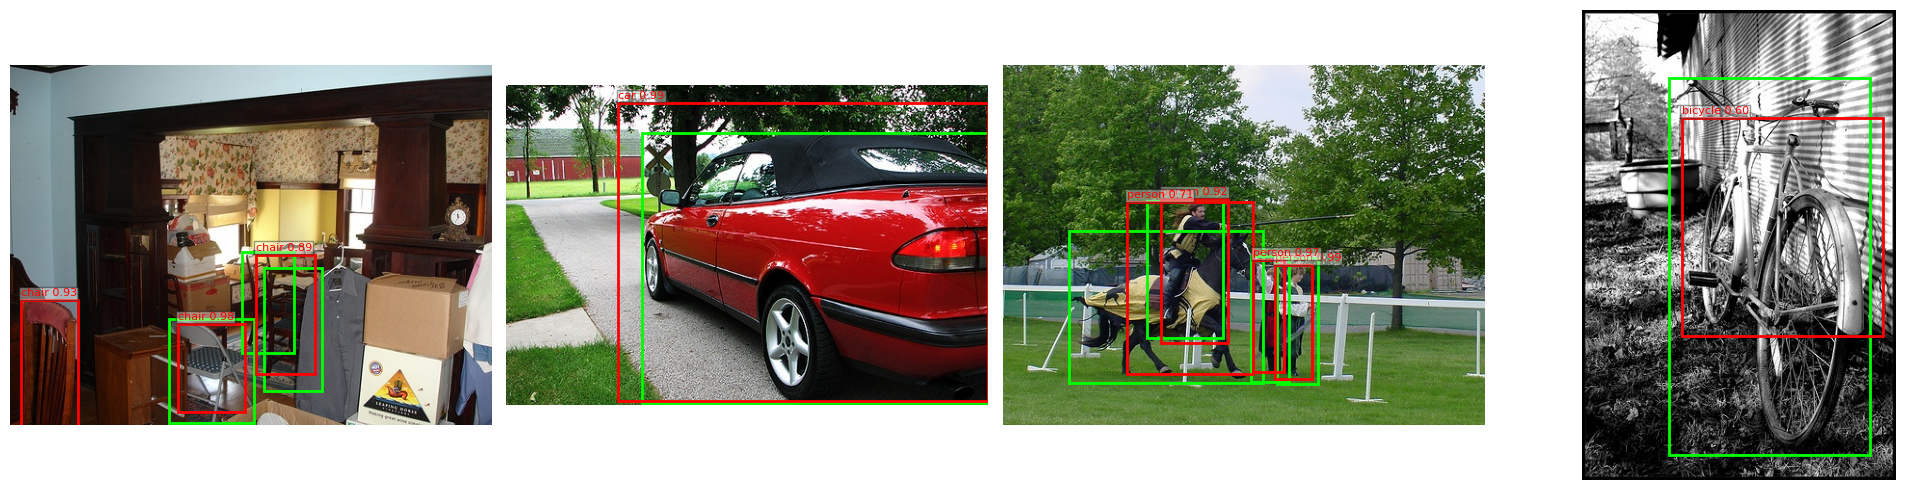

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONF_THRESH = 0.5

def get_model(weights_path):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 21)
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def visualize(model, dataset, n=4):
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for ax, idx in zip(axes, range(n)):
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            pred = model([img_tensor.to(DEVICE)])[0]

        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Ground truth — green
        for box in target["boxes"]:
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))

        # Predictions — red, filtered by confidence
        keep = pred["scores"] >= CONF_THRESH
        for box, label, score in zip(
            pred["boxes"][keep].cpu(),
            pred["labels"][keep].cpu(),
            pred["scores"][keep].cpu()
        ):
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x1, y1 - 4,
                    f"{VOC_CLASSES[label.item()]} {score:.2f}",
                    color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.4, pad=1))

        ax.axis("off")

    plt.tight_layout()
    plt.savefig("viz_output.png", dpi=150)
    plt.show()

# --- run ---
# Use best checkpoint if it was saved, otherwise final
import os
ckpt = "/kaggle/working/faster_rcnn_best.pth" if os.path.exists("faster_rcnn_best.pth") else "faster_rcnn_final.pth"

model = get_model(ckpt)
val_ds = Subset(VOCDataset(split="val"), range(100))
visualize(model, val_ds, n=4)

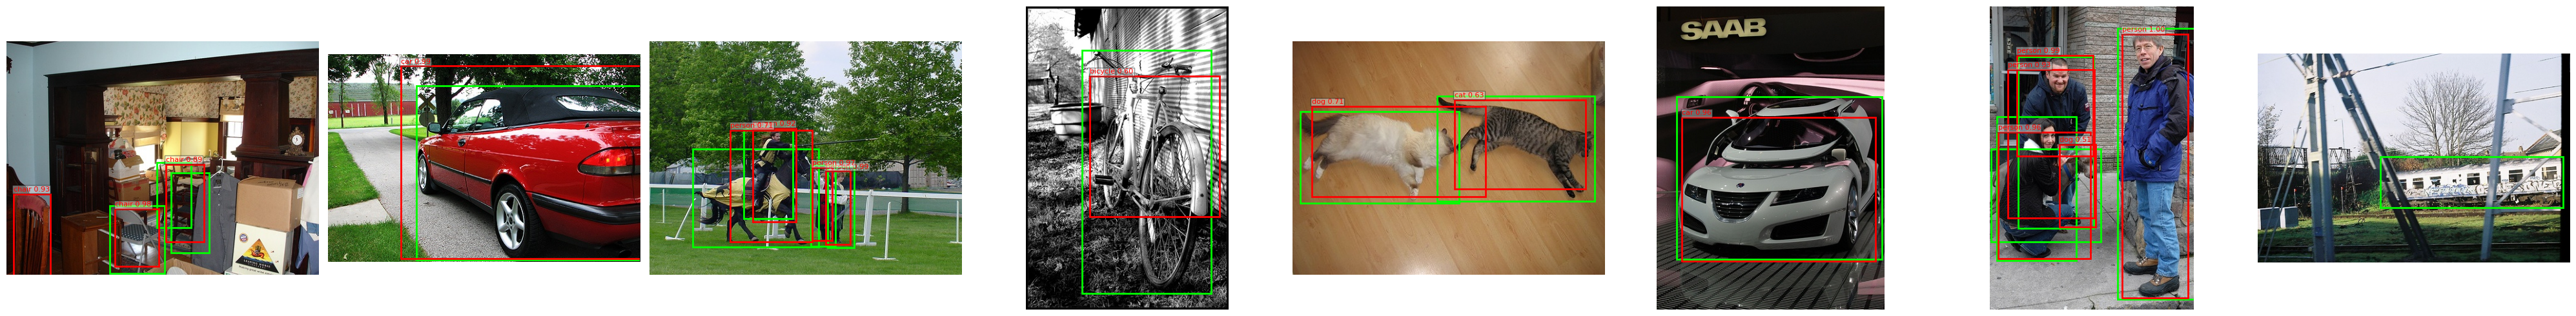

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONF_THRESH = 0.5

def get_model(weights_path):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 21)
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def visualize(model, dataset, n=4):
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for ax, idx in zip(axes, range(n)):
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            pred = model([img_tensor.to(DEVICE)])[0]

        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Ground truth — green
        for box in target["boxes"]:
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))

        # Predictions — red, filtered by confidence
        keep = pred["scores"] >= CONF_THRESH
        for box, label, score in zip(
            pred["boxes"][keep].cpu(),
            pred["labels"][keep].cpu(),
            pred["scores"][keep].cpu()
        ):
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x1, y1 - 4,
                    f"{VOC_CLASSES[label.item()]} {score:.2f}",
                    color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.4, pad=1))

        ax.axis("off")

    plt.tight_layout()
    plt.savefig("viz_output.png", dpi=150)
    plt.show()

# --- run ---
# Use best checkpoint if it was saved, otherwise final
import os
ckpt = "/kaggle/working/faster_rcnn_best.pth" if os.path.exists("faster_rcnn_best.pth") else "faster_rcnn_final.pth"

model = get_model(ckpt)
val_ds = Subset(VOCDataset(split="val"), range(100))
visualize(model, val_ds, n=8)